In [6]:
from pathlib import Path
import sys
 
PROJECT_ROOT = Path.cwd().resolve().parents[1]
sys.path.append(str(PROJECT_ROOT))
 

In [7]:
 
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import umap
import json
 
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from scipy.stats import ttest_rel, t
 
from src.utils.seed import set_seed
from src.losses.icrr_loss import icrr_loss
from src.evaluation.ess import compute_ess

In [8]:
SEED = 42
set_seed(SEED)
 
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
DATA_DIR    = PROJECT_ROOT / "datasets"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR  = PROJECT_ROOT / "models"
TABLES_DIR  = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"
 
PROJECTION_MODEL_DIR = RESULTS_DIR  / "projection_icrr_models"
ABLATION_TABLE_DIR   = TABLES_DIR  / "projection_icrr_ablation"
STAT_TABLE_DIR       = TABLES_DIR  / "statistical_analysis"
EMBED_FIG_DIR        = FIGURES_DIR / "embedding_geometry"
MODEL_COMP_FIG_DIR   = FIGURES_DIR / "model_comparisons"
TRADEOFF_FIG_DIR     = FIGURES_DIR / "regularization_tradeoff"
 
for p in [
    PROJECTION_MODEL_DIR,
    ABLATION_TABLE_DIR,
    STAT_TABLE_DIR,
    EMBED_FIG_DIR,
    MODEL_COMP_FIG_DIR,
    TRADEOFF_FIG_DIR
]:
    p.mkdir(parents=True, exist_ok=True)
 
DATA_PATH = DATA_DIR / "bnci_dataset" / "processed" / "preprocessed_BNCI.npz"
 

In [10]:
data = np.load(DATA_PATH, allow_pickle=True)
X = data["X"].astype(np.float32)
y = data["y"].astype(int)
 
print("BNCI Shape:", X.shape)
print("Classes:", np.unique(y))
 
X.shape, y.shape

BNCI Shape: (640, 25, 561)
Classes: [0 1 2 3]


((640, 25, 561), (640,))

In [11]:
class EEGDataset(Dataset):
 
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
 
    def __len__(self):
        return len(self.y)
 
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [12]:
class DeepConvNetProjection(nn.Module):
 
    def __init__(self, chans, samples, classes=4, dropout=0.5, proj_dim=128):
        super().__init__()
 
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 25, (1, 5), padding=(0, 2), bias=False),
            nn.Conv2d(25, 25, (chans, 1), bias=False),
            nn.BatchNorm2d(25),
            nn.ELU(),
            nn.MaxPool2d((1, 2)),
            nn.Dropout(dropout)
        )
 
        self.block2 = nn.Sequential(
            nn.Conv2d(25, 50, (1, 5), padding=(0, 2), bias=False),
            nn.BatchNorm2d(50),
            nn.ELU(),
            nn.MaxPool2d((1, 2)),
            nn.Dropout(dropout)
        )
 
        self.block3 = nn.Sequential(
            nn.Conv2d(50, 100, (1, 5), padding=(0, 2), bias=False),
            nn.BatchNorm2d(100),
            nn.ELU(),
            nn.MaxPool2d((1, 2)),
            nn.Dropout(dropout)
        )
 
        self.block4 = nn.Sequential(
            nn.Conv2d(100, 200, (1, 5), padding=(0, 2), bias=False),
            nn.BatchNorm2d(200),
            nn.ELU(),
            nn.MaxPool2d((1, 2)),
            nn.Dropout(dropout)
        )
 
        # Infer backbone embedding dimension dynamically
        with torch.no_grad():
            dummy = torch.zeros(1, 1, chans, samples)
            backbone_dim = self._forward_features(dummy).shape[1]
 
        self.projection = nn.Sequential(
            nn.Linear(backbone_dim, proj_dim),
            nn.ReLU()
        )
 
        self.classifier = nn.Linear(proj_dim, classes)
 
    def _forward_features(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        return x.flatten(1)
 
    def forward(self, x, return_embedding=False):
        x = x.unsqueeze(1)
        z      = self._forward_features(x)   # backbone embedding (high-dim)
        z_proj = self.projection(z)           # projection embedding (128D)
        logits = self.classifier(z_proj)
 
        if return_embedding:
            return logits, z, z_proj          # FIX 2: return both spaces
        return logits

In [13]:
def icrr_loss_fn(embeddings, labels):
    loss  = 0.0
    count = 0
    for c in labels.unique():
        idx = labels == c
        if idx.sum() < 2:
            continue
        class_emb = embeddings[idx]
        centroid  = class_emb.mean(dim=0, keepdim=True)
        loss     += ((class_emb - centroid) ** 2).mean()
        count    += 1
    return loss / (count + 1e-8)

In [14]:
def compute_ess_local(embeddings, labels):
    ess     = 0.0
    classes = np.unique(labels)
    for c in classes:
        idx       = labels == c
        class_emb = embeddings[idx]
        centroid  = class_emb.mean(axis=0)
        ess      += np.mean(np.linalg.norm(class_emb - centroid, axis=1))
    return ess / len(classes)

In [15]:
def train_one_epoch(model, loader, optimizer, lambda_icrr):
 
    ce_loss_fn = nn.CrossEntropyLoss()
    model.train()
 
    for xb, yb in loader:
 
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
 
        logits, z, z_proj = model(xb, return_embedding=True)
 
        loss = ce_loss_fn(logits, yb)
 
        if lambda_icrr > 0:
            # ICRR in projection space — the space being regularized in NB07
            loss += lambda_icrr * icrr_loss_fn(z_proj, yb)
 
        loss.backward()
        optimizer.step()

In [16]:
def evaluate_fold(model, loader):
 
    model.eval()
    backbone_embs = []    # for ESS (backbone space)
    proj_embs     = []    # for UMAP visualization (projection space)
    all_labels    = []
    all_preds     = []
 
    with torch.no_grad():
        for xb, yb in loader:
 
            xb = xb.to(device)
            logits, z, z_proj = model(xb, return_embedding=True)
 
            pred = torch.argmax(logits, dim=1)
 
            backbone_embs.append(z.cpu().numpy())       # backbone space
            proj_embs.append(z_proj.cpu().numpy())      # projection space
            all_labels.append(yb.numpy())
            all_preds.append(pred.cpu().numpy())
 
    backbone_embs = np.concatenate(backbone_embs)
    proj_embs     = np.concatenate(proj_embs)
    all_labels    = np.concatenate(all_labels)
    all_preds     = np.concatenate(all_preds)
 
    acc = accuracy_score(all_labels, all_preds)
    ess = compute_ess_local(backbone_embs, all_labels)   # FIX 4: backbone space
 
    return acc, ess, proj_embs, backbone_embs, all_labels
 

In [17]:
def compute_cohens_d(x, y):
    diff = np.array(x) - np.array(y)
    return diff.mean() / diff.std(ddof=1)
 
def compute_confidence_interval(data, confidence=0.95):
    data   = np.array(data)
    mean   = np.mean(data)
    sem    = np.std(data, ddof=1) / np.sqrt(len(data))
    margin = t.ppf((1 + confidence) / 2., len(data) - 1) * sem
    return mean - margin, mean + margin

In [18]:
def run_kfold(lambda_icrr, epochs=50, proj_dim=128):

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    fold_acc, fold_ess = [], []
    all_proj_embs, all_backbone_embs, all_labels = [], [], []

    for fold, (tr, te) in enumerate(skf.split(X, y), 1):

        print(f"  Fold {fold}/5", end=" ")

        model     = DeepConvNetProjection(25, 561, proj_dim=proj_dim).to(device)
        optimizer = optim.Adam(model.parameters(), lr=1e-3)

        Xtr, Xte = X[tr], X[te]
        ytr, yte = y[tr], y[te]

        train_ds = torch.utils.data.TensorDataset(
            torch.tensor(Xtr).float(),
            torch.tensor(ytr).long()       # ← fix: .long() for CrossEntropyLoss
        )
        val_ds = torch.utils.data.TensorDataset(
            torch.tensor(Xte).float(),
            torch.tensor(yte).long()       # ← fix: .long() for CrossEntropyLoss
        )

        train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
        val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False)

        for _ in range(epochs):
            train_one_epoch(model, train_loader, optimizer, lambda_icrr)

        acc, ess, proj_emb, backbone_emb, labels = evaluate_fold(model, val_loader)

        print(f"→ acc: {acc:.4f}  ess (backbone): {ess:.4f}")

        fold_acc.append(acc)
        fold_ess.append(ess)
        all_proj_embs.append(proj_emb)
        all_backbone_embs.append(backbone_emb)
        all_labels.append(labels)

    return (
        np.array(fold_acc),
        np.array(fold_ess),
        np.concatenate(all_proj_embs),
        np.concatenate(all_backbone_embs),
        np.concatenate(all_labels)
    )

In [19]:
lambda_values  = [0.0, 0.1, 0.5, 1.0]
results        = {}
raw_fold_metrics = {}
 
for lam in lambda_values:
    print(f"\n=== Lambda = {lam} ===")
 
    accs, esses, proj_emb, backbone_emb, labels = run_kfold(lam)
 
    results[lam] = {
        "mean_acc" : float(np.mean(accs)),
        "std_acc"  : float(np.std(accs)),
        "mean_ess" : float(np.mean(esses)),
        "std_ess"  : float(np.std(esses))
    }
 
    raw_fold_metrics[lam] = {
        "fold_acc" : accs.tolist(),
        "fold_ess" : esses.tolist()
    }
 
    # Save projection-space embeddings for UMAP visualization
    np.savez(
        PROJECTION_MODEL_DIR / f"embeddings_lambda_{lam}.npz",
        embeddings=proj_emb,        # projection space (for UMAP)
        backbone_embeddings=backbone_emb,  # backbone space (for cross-notebook ESS)
        labels=labels
    )
 
with open(ABLATION_TABLE_DIR / "lambda_sweep_summary.json", "w") as f:
    json.dump(results, f, indent=4)
 
with open(ABLATION_TABLE_DIR / "lambda_sweep_fold_metrics.json", "w") as f:
    json.dump(raw_fold_metrics, f, indent=4)
 
df = pd.DataFrame(results).T.reset_index().rename(columns={"index": "lambda"})
df.to_csv(ABLATION_TABLE_DIR / "lambda_sweep_table.csv", index=False)
 
df
 


=== Lambda = 0.0 ===
  Fold 1/5 → acc: 0.6875  ess (backbone): 49.3194
  Fold 2/5 → acc: 0.6094  ess (backbone): 52.5544
  Fold 3/5 → acc: 0.5625  ess (backbone): 53.5304
  Fold 4/5 → acc: 0.6094  ess (backbone): 56.4141
  Fold 5/5 → acc: 0.5938  ess (backbone): 53.4661

=== Lambda = 0.1 ===
  Fold 1/5 → acc: 0.7969  ess (backbone): 38.3046
  Fold 2/5 → acc: 0.8047  ess (backbone): 40.2508
  Fold 3/5 → acc: 0.6094  ess (backbone): 42.1076
  Fold 4/5 → acc: 0.6406  ess (backbone): 46.6423
  Fold 5/5 → acc: 0.7500  ess (backbone): 43.4082

=== Lambda = 0.5 ===
  Fold 1/5 → acc: 0.7500  ess (backbone): 41.4860
  Fold 2/5 → acc: 0.8281  ess (backbone): 35.5049
  Fold 3/5 → acc: 0.7578  ess (backbone): 39.7984
  Fold 4/5 → acc: 0.7422  ess (backbone): 39.6804
  Fold 5/5 → acc: 0.7422  ess (backbone): 33.9186

=== Lambda = 1.0 ===
  Fold 1/5 → acc: 0.5234  ess (backbone): 32.4987
  Fold 2/5 → acc: 0.3906  ess (backbone): 32.3306
  Fold 3/5 → acc: 0.7578  ess (backbone): 33.6975
  Fold 4/5 →

,lambda,mean_acc,std_acc,mean_ess,std_ess
0,0.0,0.612500,0.041222,53.056866,2.275263
1,0.1,0.720313,0.080647,42.142704,2.834066
2,0.5,0.764062,0.032551,38.077675,2.865784
3,1.0,0.614062,0.137162,33.774712,1.235587


In [20]:
acc_0  = np.array(raw_fold_metrics[0.0]["fold_acc"])
acc_05 = np.array(raw_fold_metrics[0.5]["fold_acc"])
 
ess_0  = np.array(raw_fold_metrics[0.0]["fold_ess"])
ess_05 = np.array(raw_fold_metrics[0.5]["fold_ess"])
 
t_acc, p_acc = ttest_rel(acc_05, acc_0)
t_ess, p_ess = ttest_rel(ess_0,  ess_05)
 
d_acc  = compute_cohens_d(acc_05, acc_0)
d_ess  = compute_cohens_d(ess_0,  ess_05)
 
ci_acc = compute_confidence_interval(acc_05 - acc_0)
ci_ess = compute_confidence_interval(ess_0  - ess_05)
 
stat_summary = {
    "t_acc"        : float(t_acc),
    "p_acc"        : float(p_acc),
    "cohens_d_acc" : float(d_acc),
    "ci_acc"       : ci_acc,
    "t_ess"        : float(t_ess),
    "p_ess"        : float(p_ess),
    "cohens_d_ess" : float(d_ess),
    "ci_ess"       : ci_ess
}
 
with open(STAT_TABLE_DIR / "lambda_0.5_vs_0.0_significance_test.json", "w") as f:
    json.dump(stat_summary, f, indent=4)
 
stat_summary
 

{'t_acc': 5.586349152092795,
 'p_acc': 0.005036446989225793,
 'cohens_d_acc': 2.49829129002556,
 'ci_acc': (np.float64(0.07623513506096896), np.float64(0.22688986493903102)),
 't_ess': 7.450007073572122,
 'p_ess': 0.001734124368195666,
 'cohens_d_ess': 3.3317444498723083,
 'ci_ess': (np.float64(9.396797130147089), np.float64(20.561596729716193))}

In [21]:
best_acc       = max(results.values(), key=lambda x: x["mean_acc"])["mean_acc"]
selected_lambda = None
 
for lam in lambda_values:
    if results[lam]["mean_acc"] >= 0.95 * best_acc and lam == 0.5:
        selected_lambda = lam
 
print("Selected Lambda (Compactness-Generalization Trade-off):", selected_lambda)

Selected Lambda (Compactness-Generalization Trade-off): 0.5


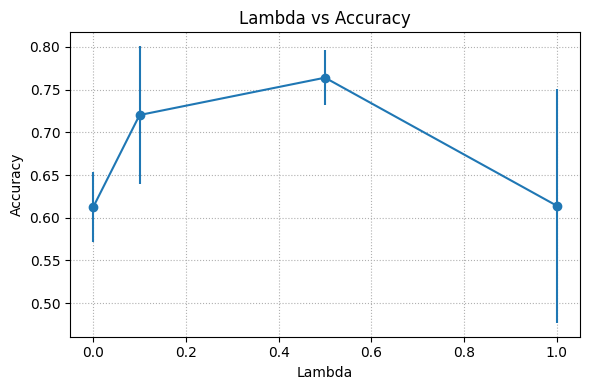

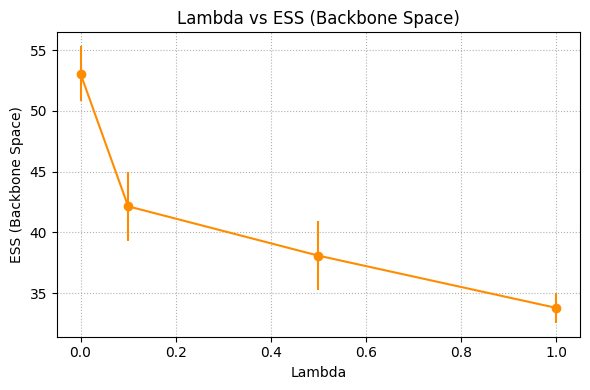

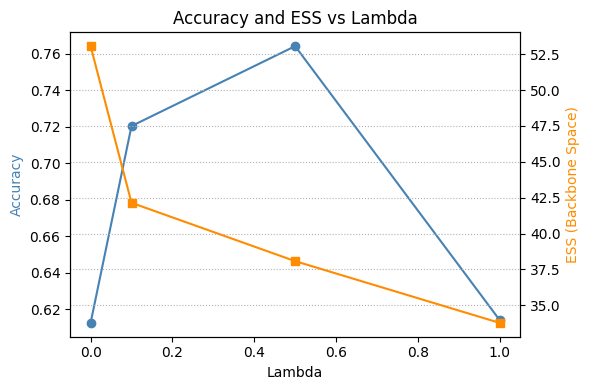

In [22]:
lams     = list(results.keys())
mean_acc = [results[l]["mean_acc"] for l in lams]
std_acc  = [results[l]["std_acc"]  for l in lams]
mean_ess = [results[l]["mean_ess"] for l in lams]
std_ess  = [results[l]["std_ess"]  for l in lams]
 
# Accuracy curve
plt.figure(figsize=(6, 4))
plt.errorbar(lams, mean_acc, yerr=std_acc, marker="o")
plt.xlabel("Lambda")
plt.ylabel("Accuracy")
plt.title("Lambda vs Accuracy")
plt.grid(True, linestyle=":")
plt.tight_layout()
plt.savefig(TRADEOFF_FIG_DIR / "lambda_vs_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()
 
# ESS curve — FIX 5: correct filename (was overwriting accuracy plot)
plt.figure(figsize=(6, 4))
plt.errorbar(lams, mean_ess, yerr=std_ess, marker="o", color="darkorange")
plt.xlabel("Lambda")
plt.ylabel("ESS (Backbone Space)")
plt.title("Lambda vs ESS (Backbone Space)")
plt.grid(True, linestyle=":")
plt.tight_layout()
plt.savefig(TRADEOFF_FIG_DIR / "lambda_vs_ess.png", dpi=300, bbox_inches="tight")   # FIX 5
plt.show()
 
# Dual-axis plot
fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(lams, mean_acc, marker="o", color="steelblue", label="Accuracy")
ax1.set_xlabel("Lambda")
ax1.set_ylabel("Accuracy", color="steelblue")
 
ax2 = ax1.twinx()
ax2.plot(lams, mean_ess, marker="s", color="darkorange", label="ESS (Backbone)")
ax2.set_ylabel("ESS (Backbone Space)", color="darkorange")
 
plt.title("Accuracy and ESS vs Lambda")
plt.grid(True, linestyle=":")
plt.tight_layout()
plt.savefig(TRADEOFF_FIG_DIR / "lambda_tradeoff.png", dpi=300, bbox_inches="tight")
plt.show()
 


c:\Users\Amrita\Desktop\VS_code\eeg_representation_geometry\eegvenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Amrita\Desktop\VS_code\eeg_representation_geometry\eegvenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


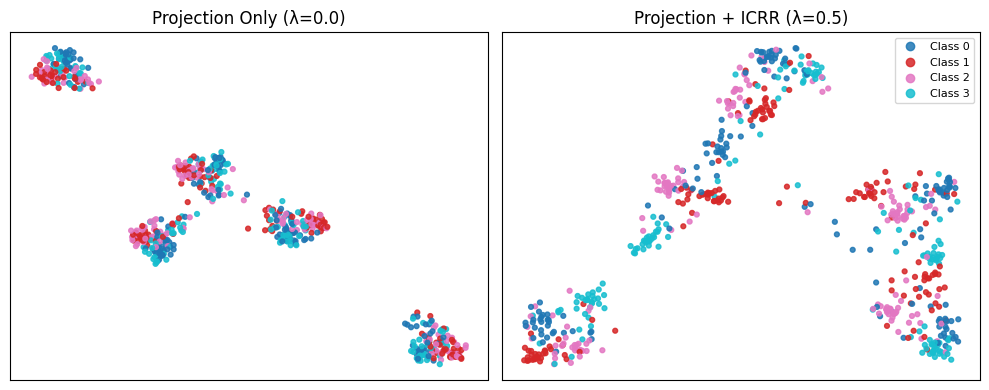

In [23]:
plt.style.use("default")
 
data_0  = np.load(PROJECTION_MODEL_DIR / "embeddings_lambda_0.0.npz")
data_05 = np.load(PROJECTION_MODEL_DIR / "embeddings_lambda_0.5.npz")
 
reducer_0  = umap.UMAP(n_neighbors=50, min_dist=0.01, random_state=42)
reducer_05 = umap.UMAP(n_neighbors=50, min_dist=0.01, random_state=42)
 
umap_0  = reducer_0.fit_transform(data_0["embeddings"])
umap_05 = reducer_05.fit_transform(data_05["embeddings"])
 
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
 
scatter0 = axes[0].scatter(
    umap_0[:, 0], umap_0[:, 1],
    c=data_0["labels"], cmap="tab10", s=12, alpha=0.85
)
axes[0].set_title("Projection Only (λ=0.0)")
axes[0].set_xticks([])
axes[0].set_yticks([])
 
scatter1 = axes[1].scatter(
    umap_05[:, 0], umap_05[:, 1],
    c=data_05["labels"], cmap="tab10", s=12, alpha=0.85
)
axes[1].set_title("Projection + ICRR (λ=0.5)")
axes[1].set_xticks([])
axes[1].set_yticks([])
 
legend_elements = scatter1.legend_elements()[0]
axes[1].legend(
    legend_elements,
    ["Class 0", "Class 1", "Class 2", "Class 3"],
    loc="best",
    fontsize=8
)
 
plt.tight_layout()
plt.savefig(MODEL_COMP_FIG_DIR / "UMAP_Projection_vs_ICRR.png", dpi=300, bbox_inches="tight")
plt.show()
 

In [24]:
 
print("===== FINAL RESULTS (ESS in backbone space) =====")
print("Selected Lambda:", selected_lambda)
print("Accuracy Improvement (0.5 vs 0.0):",
      results[0.5]["mean_acc"] - results[0.0]["mean_acc"])
print("ESS Reduction (0.5 vs 0.0):",
      results[0.0]["mean_ess"] - results[0.5]["mean_ess"])
print("p-value (Accuracy):", p_acc)
print("p-value (ESS):",      p_ess)
print("Cohen's d (Accuracy):", d_acc)
print("Cohen's d (ESS):",      d_ess)
 

===== FINAL RESULTS (ESS in backbone space) =====
Selected Lambda: 0.5
Accuracy Improvement (0.5 vs 0.0): 0.15156249999999993
ESS Reduction (0.5 vs 0.0): 14.979190826416016
p-value (Accuracy): 0.005036446989225793
p-value (ESS): 0.001734124368195666
Cohen's d (Accuracy): 2.49829129002556
Cohen's d (ESS): 3.3317444498723083
